<a href="https://colab.research.google.com/github/jsarroyo91-ops/Aprendizaje-Autom-tico/blob/main/Metricas_Evaluacion_y_modelos_clasificacion_AA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Importanción de Librerías


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset
from sklearn.datasets import load_breast_cancer

# División entrenamiento / prueba
from sklearn.model_selection import train_test_split

# Preprocesamiento y pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Modelo
from sklearn.linear_model import LogisticRegression

# Métricas
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    accuracy_score
)

# Validación cruzada
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Optimización de hiperparámetros
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [25]:

# CARGAR DATASET BREAST CANCER
# El dataset breast_cancer contiene información médica de tumores.
# Cada fila representa un caso y cada columna representa una característica.

cancer = load_breast_cancer()
print("Clases:", cancer.target_names) # mostrar orden de maligno o benigno

X = cancer.data   # variable independiente características del tumor (radio, textura, perímetro, area del tumor)
y_original = cancer.target  # variable dependiente, clases a predecir (tumor maligno o benigno)

# Invertimos las clases para que:
# 0 = benign
# 1 = malignant
y = 1 - y_original

# Nombres corregidos de las clases según la nueva codificación
nombres_clases = ["benign", "malignant"]

# Convertir a DataFrame para visualizar mejor
df = pd.DataFrame(
    X,
    columns=cancer.feature_names
)

df["target"] = y

print("Dimensiones del dataset:", df.shape)
print("Clases usadas:", nombres_clases)
print(df.head())

Clases: ['malignant' 'benign']
Dimensiones del dataset: (569, 31)
Clases usadas: ['benign', 'malignant']
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430       

In [26]:
# DIVIDIR DATOS EN ENTRENAMIENTO Y PRUEBA
# El conjunto de entrenamiento se usa para que el modelo aprenda.
# El conjunto de prueba se usa para evaluar el modelo con datos nuevos.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,                               # - 30 % de los datos serán para prueba.
    random_state=42,
    stratify=y                                    # stratify=y mantiene la misma proporción de clases benignas y malignas en entrenamiento y prueba
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (398, 30)
Datos de prueba: (171, 30)


In [27]:
# CREAR Y ENTRENAR MODELO DE REGRESIÓN LOGÍSTICA

modelo = Pipeline([
    ("scaler", StandardScaler()),    # estandariza variables para que tenga una media 0 y desviacion 1
    ("logistic", LogisticRegression( # modelo para aprender la relación entre X y y
        max_iter=5000,
        random_state=42
    ))
])

modelo.fit(X_train, y_train)         # Entrenamiento del modelo

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


In [28]:
# GENERAR PREDICCIONES

y_pred = modelo.predict(X_test)                 # contiene la clase predicha por el modelo 0= benigno, 1= maligno

# Probabilidad de pertenecer a la clase positiva
# En este dataset, clase 1 = maligno
y_prob = modelo.predict_proba(X_test)[:, 1]

print("Primeras predicciones:")
print(y_pred[:10])

print("\nPrimeras probabilidades:")
print(y_prob[:10])

Primeras predicciones:
[0 0 0 0 0 0 1 0 1 0]

Primeras probabilidades:
[1.13378349e-01 2.32412069e-03 9.07292766e-05 3.10246072e-03
 1.90233256e-02 1.37934228e-03 9.99865101e-01 1.10998366e-02
 8.98957187e-01 1.91212041e-03]


Matriz de confusión:
[[106   1]
 [  4  60]]


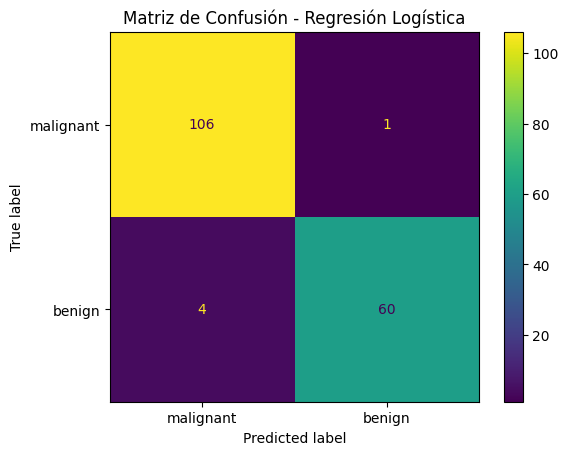

TN - Verdaderos negativos: 106
FP - Falsos positivos: 1
FN - Falsos negativos: 4
TP - Verdaderos positivos: 60


In [29]:
# MATRIZ DE CONFUSIÓN
# La matriz de confusión compara:
# - las clases reales,
# - con las clases predichas por el modelo.

cm = confusion_matrix(y_test, y_pred)

print("Matriz de confusión:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=cancer.target_names
)

disp.plot()
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()


# EXTRAER VALORES DE LA MATRIZ


tn, fp, fn, tp = cm.ravel()

print("TN - Verdaderos negativos:", tn)
print("FP - Falsos positivos:", fp)
print("FN - Falsos negativos:", fn)
print("TP - Verdaderos positivos:", tp)

In [30]:
# MÉTRICAS DE EVALUACIÓN


accuracy = accuracy_score(y_test, y_pred)     # Total de aciertos
precision = precision_score(y_test, y_pred)   # Predicciones positivas correctas
recall = recall_score(y_test, y_pred)         # Casos reales positivos detectados por el modelo
f1 = f1_score(y_test, y_pred)                 # Combinación de presicion y recall en una metrica
auc = roc_auc_score(y_test, y_prob)           # Mide la capacidad del modelo de separar correctamente ambas clases

print("Accuracy:", round(accuracy, 4))
print("Precisión:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-Score:", round(f1, 4))
print("AUC-ROC:", round(auc, 4))

print("\nReporte de clasificación:")
print(
    classification_report(                   # presenta un resumen completo por clase
        y_test,
        y_pred,
        target_names=cancer.target_names
    )
)

Accuracy: 0.9708
Precisión: 0.9836
Recall: 0.9375
F1-Score: 0.96
AUC-ROC: 0.9975

Reporte de clasificación:
              precision    recall  f1-score   support

   malignant       0.96      0.99      0.98       107
      benign       0.98      0.94      0.96        64

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



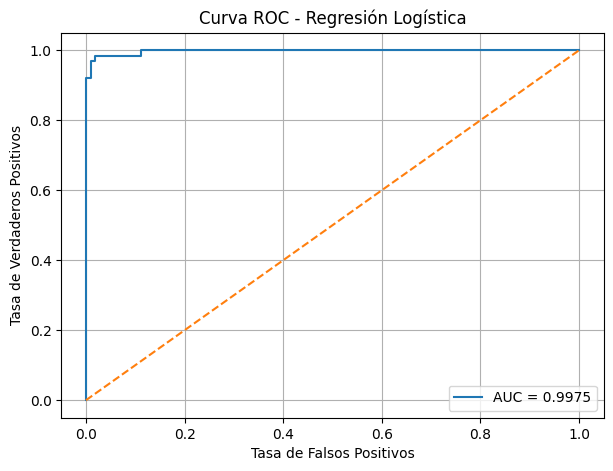

In [31]:
# CURVA ROC
# La curva ROC muestra el comportamiento del modelo para distintos
# umbrales de decisión.
#
# fpr = tasa de falsos positivos.
# tpr = tasa de verdaderos positivos, también llamada recall.
#
# Mientras más cerca esté la curva de la esquina superior izquierda, mejor sera el modelo


fpr, tpr, thresholds = roc_curve(y_test, y_prob)    # muestra la relación entre la tasa de verdaderos positivos y la tasa de falsos positivos

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")             # representa un clasificador aleatorio

plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curva ROC - Regresión Logística")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
#  VALIDACIÓN CRUZADA K-FOLD

# la validadción crizada divide el dataset en varias partes (k) y entrena el modelo varias veces
# evalua el rendimiento en diferentes particiones

modelo_cv = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

# StratifiedKFold mantiene la proporción de clases en cada fold.
#
# Se evaluará el modelo con:
# - k = 5
# - k = 10

# K = 5
cv_5 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores_5 = cross_val_score(
    modelo_cv,
    X,
    y,
    cv=cv_5,
    scoring="roc_auc"            # se usa scoring roc auc para comparar los modelos segun la capacidad de discriminacion entre clases
)

# K = 10
cv_10 = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

scores_10 = cross_val_score(
    modelo_cv,
    X,
    y,
    cv=cv_10,
    scoring="roc_auc"
)

print("Resultados K-Fold con k=5")
print("Scores:", scores_5)
print("Media:", round(scores_5.mean(), 4))
print("Desviación estándar:", round(scores_5.std(), 4))

print("\nResultados K-Fold con k=10")
print("Scores:", scores_10)
print("Media:", round(scores_10.mean(), 4))
print("Desviación estándar:", round(scores_10.std(), 4))

Resultados K-Fold con k=5
Scores: [0.9950868  0.99770717 0.98511905 1.         0.99865862]
Media: 0.9953
Desviación estándar: 0.0053

Resultados K-Fold con k=10
Scores: [0.99220779 0.9987013  0.99603175 0.99603175 0.97751323 0.99074074
 1.         1.         0.99603175 1.        ]
Media: 0.9947
Desviación estándar: 0.0065


In [33]:

# COMPARACIÓN K=5 VS K=10

# Se crea una tabla para comparar:
# - AUC promedio,
# - desviación estándar.
#
# Una media alta indica buen rendimiento.
# Una desviación estándar baja indica mayor estabilidad.

comparacion_cv = pd.DataFrame({
    "k": [5, 10],
    "AUC_ROC_promedio": [
        scores_5.mean(),
        scores_10.mean()
    ],
    "Desviacion_estandar": [
        scores_5.std(),
        scores_10.std()
    ]
})

print(comparacion_cv)

    k  AUC_ROC_promedio  Desviacion_estandar
0   5          0.995314             0.005345
1  10          0.994726             0.006503


In [34]:

# OPTIMIZACIÓN CON GRIDSEARCHCV
# busca mejor optimización de hiperparámetros de la regresión logistica
# C:
# Controla la regularización.
# Valores pequeños implican mayor regularización.
# Valores grandes implican menor regularización.
#
# penalty:
# Tipo de penalización aplicada al modelo.
#
# solver:
# Algoritmo usado para resolver la Regresión Logística.

pipeline_grid = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

param_grid = {
    "logistic__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "logistic__penalty": ["l2"],                            # combinaciones a evaluar
    "logistic__solver": ["lbfgs", "liblinear"]
}

grid_search = GridSearchCV(
    estimator=pipeline_grid,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros GridSearchCV:")
print(grid_search.best_params_)

print("\nMejor AUC promedio en validación:")
print(round(grid_search.best_score_, 4))

Mejores hiperparámetros GridSearchCV:
{'logistic__C': 0.1, 'logistic__penalty': 'l2', 'logistic__solver': 'liblinear'}

Mejor AUC promedio en validación:
0.9918


In [35]:
# EVALUAR MEJOR MODELO DE GRIDSEARCHCV
# Se toma el mejor modelo encontrado por GridSearchCV.
# Luego se evalúa con el conjunto de prueba.

mejor_modelo_grid = grid_search.best_estimator_

y_pred_grid = mejor_modelo_grid.predict(X_test)
y_prob_grid = mejor_modelo_grid.predict_proba(X_test)[:, 1]

print("Métricas del modelo optimizado con GridSearchCV")

print("Accuracy:", round(accuracy_score(y_test, y_pred_grid), 4))
print("Precisión:", round(precision_score(y_test, y_pred_grid), 4))
print("Recall:", round(recall_score(y_test, y_pred_grid), 4))
print("F1-Score:", round(f1_score(y_test, y_pred_grid), 4))
print("AUC-ROC:", round(roc_auc_score(y_test, y_prob_grid), 4))

Métricas del modelo optimizado con GridSearchCV
Accuracy: 0.9883
Precisión: 1.0
Recall: 0.9688
F1-Score: 0.9841
AUC-ROC: 0.999


In [36]:
# OPTIMIZACIÓN CON RANDOMIZEDSEARCHCV
# RandomizedSearchCV no prueba todas las combinaciones posibles.
# En su lugar, selecciona un número limitado de combinaciones
# aleatorias.
# Como cv = 5, cada combinación se evalúa 5 veces.
# Entonces:
#   20 combinaciones x 5 folds = 100 entrenamientos

pipeline_random = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        max_iter=5000,
        random_state=42
    ))
])

param_random = {
    "logistic__C": np.logspace(-4, 4, 100),
    "logistic__penalty": ["l2"],
    "logistic__solver": ["lbfgs", "liblinear"]
}

random_search = RandomizedSearchCV(
    estimator=pipeline_random,
    param_distributions=param_random,
    n_iter=20,                             # combinaciones a evaluar
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Mejores hiperparámetros RandomizedSearchCV:")
print(random_search.best_params_)

print("\nMejor AUC promedio en validación:")
print(round(random_search.best_score_, 4))

Mejores hiperparámetros RandomizedSearchCV:
{'logistic__solver': 'liblinear', 'logistic__penalty': 'l2', 'logistic__C': np.float64(0.055908101825122285)}

Mejor AUC promedio en validación:
0.9918


In [37]:
# EVALUAR MEJOR MODELO DE RANDOMIZEDSEARCHCV
# Se toma el mejor modelo encontrado por RandomizedSearchCV.
# Luego se evalúa con los datos de prueba.

mejor_modelo_random = random_search.best_estimator_

y_pred_random = mejor_modelo_random.predict(X_test)
y_prob_random = mejor_modelo_random.predict_proba(X_test)[:, 1]

print("Métricas del modelo optimizado con RandomizedSearchCV")

print("Accuracy:", round(accuracy_score(y_test, y_pred_random), 4))
print("Precisión:", round(precision_score(y_test, y_pred_random), 4))
print("Recall:", round(recall_score(y_test, y_pred_random), 4))
print("F1-Score:", round(f1_score(y_test, y_pred_random), 4))
print("AUC-ROC:", round(roc_auc_score(y_test, y_prob_random), 4))

Métricas del modelo optimizado con RandomizedSearchCV
Accuracy: 0.9883
Precisión: 1.0
Recall: 0.9688
F1-Score: 0.9841
AUC-ROC: 0.999


In [38]:

# COMPARACIÓN DE MODELOS
# Se crea una tabla comparativa con tres modelos

resultados = pd.DataFrame({
    "Modelo": [
        "Regresión Logística base",
        "GridSearchCV",
        "RandomizedSearchCV"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_grid),
        accuracy_score(y_test, y_pred_random)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_grid),
        precision_score(y_test, y_pred_random)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_grid),
        recall_score(y_test, y_pred_random)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_grid),
        f1_score(y_test, y_pred_random)
    ],
    "AUC_ROC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, y_prob_grid),
        roc_auc_score(y_test, y_prob_random)
    ]
})

print(resultados.round(4))

                     Modelo  Accuracy  Precision  Recall      F1  AUC_ROC
0  Regresión Logística base    0.9708     0.9836  0.9375  0.9600   0.9975
1              GridSearchCV    0.9883     1.0000  0.9688  0.9841   0.9990
2        RandomizedSearchCV    0.9883     1.0000  0.9688  0.9841   0.9990


In [39]:

# AJUSTE DEL UMBRAL DE DECISIÓN
# Por defecto, el modelo clasifica como positivo si:
#
#   probabilidad >= 0.5
#
# Sin embargo, en problemas médicos puede ser útil bajar el umbral
# para detectar más casos malignos.


# Usaremos el mejor modelo obtenido por GridSearchCV
modelo_umbral = mejor_modelo_grid

# Probabilidades de clase positiva
y_prob_umbral = modelo_umbral.predict_proba(X_test)[:, 1]

umbrales = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

resultados_umbral = []

for umbral in umbrales:

    y_pred_umbral = (y_prob_umbral >= umbral).astype(int)

    precision_u = precision_score(y_test, y_pred_umbral)
    recall_u = recall_score(y_test, y_pred_umbral)
    f1_u = f1_score(y_test, y_pred_umbral)
    accuracy_u = accuracy_score(y_test, y_pred_umbral)

    resultados_umbral.append({
        "Umbral": umbral,
        "Accuracy": accuracy_u,
        "Precision": precision_u,
        "Recall": recall_u,
        "F1": f1_u
    })

df_umbral = pd.DataFrame(resultados_umbral)

print(df_umbral.round(4))

   Umbral  Accuracy  Precision  Recall      F1
0     0.2    0.9532     0.9000  0.9844  0.9403
1     0.3    0.9708     0.9403  0.9844  0.9618
2     0.4    0.9942     1.0000  0.9844  0.9921
3     0.5    0.9883     1.0000  0.9688  0.9841
4     0.6    0.9649     1.0000  0.9062  0.9508
5     0.7    0.9474     1.0000  0.8594  0.9244
6     0.8    0.9357     1.0000  0.8281  0.9060


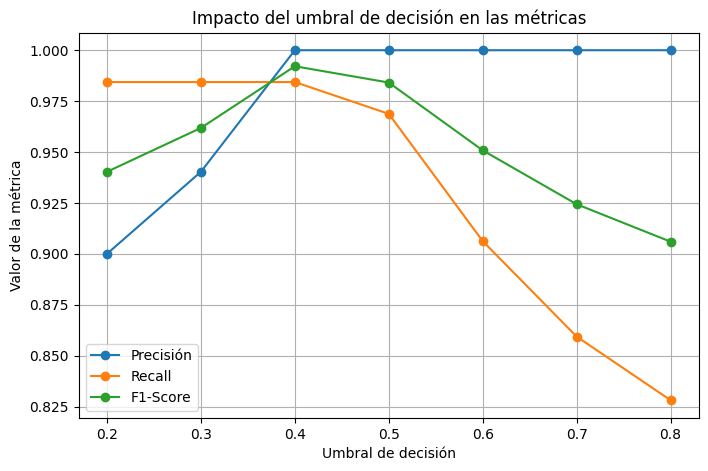

In [40]:

# GRAFICAR IMPACTO DEL UMBRAL
# Esta gráfica muestra cómo cambian Precision, Recall y F1
# cuando se modifica el umbral de decisión.

plt.figure(figsize=(8, 5))

plt.plot(
    df_umbral["Umbral"],
    df_umbral["Precision"],
    marker="o",
    label="Precisión"
)

plt.plot(
    df_umbral["Umbral"],
    df_umbral["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    df_umbral["Umbral"],
    df_umbral["F1"],
    marker="o",
    label="F1-Score"
)

plt.xlabel("Umbral de decisión")
plt.ylabel("Valor de la métrica")
plt.title("Impacto del umbral de decisión en las métricas")
plt.legend()
plt.grid(True)
plt.show()

In [41]:

# IDENTIFICAR MEJOR UMBRAL SEGÚN F1 SCORE


mejor_fila = df_umbral.loc[
    df_umbral["F1"].idxmax()                   # idxmax() busca la fila donde F1 alcanza su valor más alto.
]

print("Mejor umbral según F1-Score:")
print(mejor_fila.round(4))

Mejor umbral según F1-Score:
Umbral       0.4000
Accuracy     0.9942
Precision    1.0000
Recall       0.9844
F1           0.9921
Name: 2, dtype: float64


In [42]:
#Evaluación general de modelos de calisificación
# Aquí se comparan:
#
# - número de combinaciones evaluadas,
# - tiempo promedio de ajuste del modelo.
#
# Esto ayuda a determinar qué método fue más eficiente.

print("Número de combinaciones evaluadas por GridSearchCV:")
print(len(grid_search.cv_results_["params"]))

print("\nNúmero de combinaciones evaluadas por RandomizedSearchCV:")
print(len(random_search.cv_results_["params"]))

print("Tiempo promedio GridSearchCV:")
print(grid_search.cv_results_["mean_fit_time"].mean())

print("\nTiempo promedio RandomizedSearchCV:")
print(random_search.cv_results_["mean_fit_time"].mean())

print("Mejor AUC GridSearchCV:")
print(grid_search.best_score_)

print("\nMejor AUC RandomizedSearchCV:")
print(random_search.best_score_)


Número de combinaciones evaluadas por GridSearchCV:
12

Número de combinaciones evaluadas por RandomizedSearchCV:
20
Tiempo promedio GridSearchCV:
0.007905336221059165

Tiempo promedio RandomizedSearchCV:
0.009450755119323728
Mejor AUC GridSearchCV:
0.9918160919540229

Mejor AUC RandomizedSearchCV:
0.9918022988505747
